# Mixed precipitation fractions → NetCDF

Reads SUMMA timestep outputs, builds **snow fraction of total** `snowfall / (rainfall + snowfall)` and a **mixed-phase** flag, and writes **CF-1.8** NetCDF files with dims **`time` × `gru`** (× **`member`** if ensemble).

**Workflow**

1. **Process once** — the processing cell writes `{catchment}_{source}_mixed_precip.nc` under each catchment’s `ensemble_generation/mixed_precip/`. Existing outputs are **skipped by default** (`overwrite=False`).
2. **Plot from disk** — visualization cells open those NetCDF paths via `output_nc_by_catchment`; they do not depend on in-memory datasets from processing.


In [9]:
import logging
import sys
from pathlib import Path

import xarray as xr

# workflow/notebooks/publication -> workflow/
workflow_dir = Path("../../").resolve()
scripts_path = workflow_dir / "scripts"
sys.path.insert(0, str(scripts_path))

import compute_mixed_precip_fractions as mpf

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")


In [ ]:
# --- Configuration (edit for your run) ---
catchments = [
    "chena",
    #"bow",
    #"tuolumne",
]

gpep_root = Path("/anvil/projects/x-ees240082/users/dcasson/gpep")

glob_pattern = "**/*.nc"
time_join = "outer"  # or "inner"
compress = False
case_name_filter = None  # optional substring on filename
overwrite = False  # set True to recompute and replace existing mixed-precip NetCDFs


def ensemble_sources_for_catchment(catchment: str) -> list:
    """Return source specs for one catchment (SUMMA dirs + deterministic flag)."""
    base = gpep_root / catchment / "ensemble_generation"
    return [
        {
            "label": "RF Ensemble",
            "input_dir": base / "rf_best_regression_static_dynamic/summa/output/complete",
            "output_nc": base / "mixed_precip" / f"{catchment}_rf_mixed_precip.nc",
            "deterministic": False,
        },
    ]


def mixed_precip_output_paths(catchment: str) -> dict[str, Path]:
    """Map source label → saved NetCDF path for one catchment."""
    return {
        spec["label"]: Path(spec["output_nc"])
        for spec in ensemble_sources_for_catchment(catchment)
    }


def build_output_nc_manifest(catchments_list: list[str] | None = None) -> dict[str, dict[str, Path]]:
    """Map catchment → source label → NetCDF path (no I/O)."""
    use = catchments if catchments_list is None else catchments_list
    return {c: mixed_precip_output_paths(c) for c in use}


def open_mixed_precip_nc(
    nc_path: Path | str,
    *,
    variables: list[str] | None = None,
) -> xr.Dataset:
    """Open a saved mixed-precip NetCDF (lazy). Optionally subset data variables."""
    nc_path = Path(nc_path)
    if not nc_path.is_file():
        raise FileNotFoundError(f"Mixed-precip NetCDF not found: {nc_path}")
    ds = xr.open_dataset(nc_path)
    if variables is None:
        return ds
    missing = [v for v in variables if v not in ds]
    if missing:
        ds.close()
        raise KeyError(f"{nc_path} missing {missing}; found {list(ds.data_vars)}")
    return ds[variables]


In [11]:
"""
def ensure_mixed_precip_netcdf(spec: dict, *, catchment: str) -> Path:
    out_path = Path(spec["output_nc"])
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists() and not overwrite:
        print(f"Skip (exists): {out_path}")
        return out_path

    print(f"Writing: {out_path}")
    mpf.write_precip_phase_netcdf(
        out_path,
        input_dir=spec["input_dir"],
        glob_pattern=glob_pattern,
        case_name_filter=case_name_filter,
        deterministic=spec["deterministic"],
        time_join=time_join,
        compress=compress,
        overwrite=overwrite,
        title=f"Mixed-phase precip — {spec['label']} ({catchment})",
        source=f"SUMMA output: {spec['input_dir']}",
        history_note=f"mixed_precip_fractions_to_netcdf.ipynb {catchment} {spec['label']}",
    )
    return out_path


# catchment → source label → NetCDF path (plotting cells read these paths)
output_nc_by_catchment: dict[str, dict[str, Path]] = {}

for catchment in catchments:
    print("### Catchment:", catchment, "###")
    output_nc_by_catchment[catchment] = {}
    for spec in ensemble_sources_for_catchment(catchment):
        #print("---", spec["label"], "---")
        out_path = ensure_mixed_precip_netcdf(spec, catchment=catchment)
        output_nc_by_catchment[catchment][spec["label"]] = out_path
        print(out_path)
"""

'\ndef ensure_mixed_precip_netcdf(spec: dict, *, catchment: str) -> Path:\n    out_path = Path(spec["output_nc"])\n    out_path.parent.mkdir(parents=True, exist_ok=True)\n\n    if out_path.exists() and not overwrite:\n        print(f"Skip (exists): {out_path}")\n        return out_path\n\n    print(f"Writing: {out_path}")\n    mpf.write_precip_phase_netcdf(\n        out_path,\n        input_dir=spec["input_dir"],\n        glob_pattern=glob_pattern,\n        case_name_filter=case_name_filter,\n        deterministic=spec["deterministic"],\n        time_join=time_join,\n        compress=compress,\n        overwrite=overwrite,\n        title=f"Mixed-phase precip — {spec[\'label\']} ({catchment})",\n        source=f"SUMMA output: {spec[\'input_dir\']}",\n        history_note=f"mixed_precip_fractions_to_netcdf.ipynb {catchment} {spec[\'label\']}",\n    )\n    return out_path\n\n\n# catchment → source label → NetCDF path (plotting cells read these paths)\noutput_nc_by_catchment: dict[str, dic

### Plotting

Run the processing cell once (or skip it if outputs already exist). All figures below read **`output_nc_by_catchment`** and open NetCDF files from disk.

To replot without reprocessing, you can rebuild the path manifest alone:

```python
output_nc_by_catchment = build_output_nc_manifest()
```

#### Snow fraction by water-year day

Plots **`snow_fraction_of_total_precip`** from saved NetCDF files.

- **One catchment**: pass `output_nc=...` (label → path dict for that catchment).
- **All catchments**: pass `output_nc_by_catchment=...` — one subplot per catchment, shared colors per source.
- **`per_gru=True`**: single catchment only; one figure per GRU.

Use `resample_for_plot` (e.g. `'MS'`) when the native timestep is too dense.


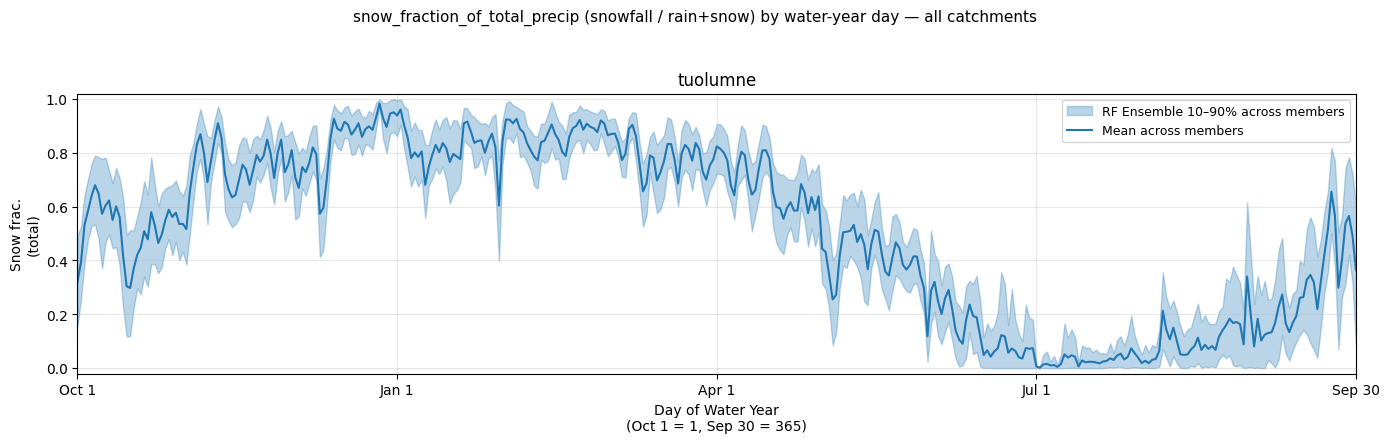

In [12]:
# Re-run this entire cell after edits so the kernel picks up the latest plotting helpers.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _open_plot_datasets(path_dict: dict[str, Path], var: str) -> dict[str, xr.Dataset]:
    """Open saved NetCDFs for plotting (lazy); caller must close via ``_close_plot_datasets``."""
    opened: dict[str, xr.Dataset] = {}
    try:
        for label, path in path_dict.items():
            opened[label] = open_mixed_precip_nc(path, variables=[var])
        return opened
    except Exception:
        _close_plot_datasets(opened)
        raise


def _close_plot_datasets(datasets: dict[str, xr.Dataset]) -> None:
    for ds in datasets.values():
        ds.close()


def _gru_ids_for_results(results: dict, var: str) -> np.ndarray:
    """GRU indices common to every dataset in ``results`` that contains ``var``."""
    common = None
    for label, ds in results.items():
        if var not in ds:
            continue
        if "gru" not in ds.dims:
            raise ValueError(f"{label}: no gru dimension — cannot plot per GRU")
        g = np.asarray(ds["gru"].values)
        common = g if common is None else np.intersect1d(common, g)
    if common is None or common.size == 0:
        raise ValueError("No overlapping GRU coordinates across results.")
    return common


def _labels_consistent_across_catchments(output_nc_by_catchment: dict) -> list:
    """Ordered source labels; raises if catchments disagree on keys."""
    if not output_nc_by_catchment:
        raise ValueError("output_nc_by_catchment is empty")
    names = list(output_nc_by_catchment.keys())
    first = output_nc_by_catchment[names[0]]
    labels = list(first.keys())
    want = set(labels)
    for cname in names[1:]:
        if set(output_nc_by_catchment[cname].keys()) != want:
            raise ValueError(
                f"Source labels differ: {names[0]} has {sorted(want)}, "
                f"{cname} has {sorted(output_nc_by_catchment[cname].keys())}"
            )
    return labels


def plot_snow_fraction_water_year_doy(
    output_nc=None,
    *,
    output_nc_by_catchment=None,
    resample_for_plot=None,
    figsize=None,
    ylim=(-0.02, 1.02),
    handle_leap_days="drop",  # 'drop' or 'keep'
    per_gru=False,
):
    """
    Snow fraction composites by **day of water-year** (Oct 1 → Sep 30), pooled over calendar years.

    Pass **either** ``output_nc`` (one catchment: label → NetCDF path) **or**
    ``output_nc_by_catchment``::

        output_nc_by_catchment = {"tuolumne": {"RF Ensemble": Path(...), ...}, ...}

    Data are read from disk; nothing is kept in memory after the figure is built.

    **Ensemble**: GRU mean (unless ``per_gru``), member mean line + 10–90% band.
    **Deterministic**: GRU mean time series (unless ``per_gru``).

    ``per_gru=True`` is only supported with ``output_nc`` (one catchment).
    """
    if (output_nc is None) == (output_nc_by_catchment is None):
        raise ValueError("Pass exactly one of `output_nc` or `output_nc_by_catchment`.")

    var = mpf.VAR_FRAC

    def water_year_and_doy(dt):
        oct1 = pd.Timestamp(year=dt.year, month=10, day=1)
        if dt >= oct1:
            wy = dt.year + 1
            doy = (dt - oct1).days + 1
        else:
            oct1_prev = pd.Timestamp(year=dt.year - 1, month=10, day=1)
            wy = dt.year
            doy = (dt - oct1_prev).days + 1
        return wy, doy

    def _color_cycle(n_labels: int) -> list:
        prop = plt.rcParams["axes.prop_cycle"].by_key().get("color", None)
        if not prop or len(prop) < n_labels:
            return ["C{}".format(i) for i in range(n_labels)]
        return list(prop)

    def plot_sources_on_ax(
        ax,
        results_in: dict,
        *,
        labels_ordered: list,
        color_cycle: list,
        gru_sel=None,
        show_legend: bool = True,
        ylabel: bool = True,
        xlabel=None,
        title=None,
    ):
        n_lbl = len(labels_ordered)
        for i, label in enumerate(labels_ordered):
            if label not in results_in:
                raise KeyError(f"missing label {label!r} in results for this panel")
            ds = results_in[label]
            if var not in ds:
                raise KeyError(f"{label}: missing {var!r}")
            da = ds[var]
            if gru_sel is None:
                da_m = da.mean(dim="gru", skipna=True)
            else:
                da_m = da.sel(gru=gru_sel)

            if resample_for_plot:
                da_m = da_m.resample(time=resample_for_plot).mean(skipna=True)
            if "member" in da_m.dims:
                da_m = da_m.transpose("time", "member")

            time_vals = pd.to_datetime(da_m["time"].values)
            wy_and_doy = [water_year_and_doy(dt) for dt in time_vals]
            all_water_years = np.array([wy for wy, doy in wy_and_doy])
            all_wydoy = np.array([doy for wy, doy in wy_and_doy])

            is_feb29 = np.array([(dt.month == 2 and dt.day == 29) for dt in time_vals])
            mask = ~is_feb29 if handle_leap_days == "drop" else np.full(len(time_vals), True)

            if "member" in da_m.dims:
                values = da_m.values
                if values.ndim == 1:
                    values = values[:, None]
                _, n_members = values.shape
                masked_values = values[mask, :]
                masked_water_years = all_water_years[mask]
                masked_wydoy = all_wydoy[mask]
                mean_per_doy = np.full((365, n_members), np.nan)
                for j in range(n_members):
                    df = pd.DataFrame(
                        {
                            "water_year": masked_water_years,
                            "wydoy": masked_wydoy,
                            "val": masked_values[:, j],
                        }
                    )
                    df = df[df["wydoy"] <= 365]
                    doy_means = (
                        df.groupby("wydoy")["val"].mean().reindex(np.arange(1, 366), fill_value=np.nan)
                    )
                    mean_per_doy[:, j] = doy_means.values
                ens_mean = np.nanmean(mean_per_doy, axis=1)
                ens_p10 = np.nanpercentile(mean_per_doy, 10, axis=1)
                ens_p90 = np.nanpercentile(mean_per_doy, 90, axis=1)
                t_ax = np.arange(1, 366)
                color = color_cycle[i % len(color_cycle)]
                ens_alpha = 0.22 + (0.08 if n_lbl <= 3 else 0)
                ax.fill_between(
                    t_ax,
                    ens_p10,
                    ens_p90,
                    alpha=ens_alpha,
                    color=color,
                    label=f"{label} 10–90% across members" if n_lbl == 1 else None,
                )
                ax.plot(
                    t_ax,
                    ens_mean,
                    color=color,
                    lw=1.5,
                    label=f"{label} mean" if n_lbl > 1 else "Mean across members",
                )
            else:
                values = da_m.values
                masked_values = values[mask]
                masked_water_years = all_water_years[mask]
                masked_wydoy = all_wydoy[mask]
                df = pd.DataFrame(
                    {
                        "water_year": masked_water_years,
                        "wydoy": masked_wydoy,
                        "val": masked_values,
                    }
                )
                df = df[df["wydoy"] <= 365]
                mean_per_doy = (
                    df.groupby("wydoy")["val"].mean().reindex(np.arange(1, 366), fill_value=np.nan)
                )
                t_ax = np.arange(1, 366)
                color = color_cycle[i % len(color_cycle)]
                ax.plot(
                    t_ax,
                    mean_per_doy.values,
                    color=color,
                    lw=1.5,
                    label=f"{label} mean" if n_lbl > 1 else "Mean across GRUs",
                )

        if ylabel:
            ax.set_ylabel("Snow frac.\n(total)")
        ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, 365)
        ax.set_xticks([1, 92, 183, 274, 365])
        ax.set_xticklabels(["Oct 1", "Jan 1", "Apr 1", "Jul 1", "Sep 30"])
        if title:
            ax.set_title(title)
        if xlabel is not None:
            ax.set_xlabel(xlabel)
        if show_legend:
            ax.legend(loc="upper right", fontsize=9)

    # --- Multi-catchment: one column of subplots, shared colors per label ---
    if output_nc_by_catchment is not None:
        if per_gru:
            raise ValueError(
                "Multi-catchment plots do not support per_gru; use `output_nc` for one catchment."
            )
        labels_ordered = _labels_consistent_across_catchments(output_nc_by_catchment)
        n_lbl = len(labels_ordered)
        n_cat = len(output_nc_by_catchment)
        if figsize is None:
            figsize = (14, max(4.5, 3.8 * n_cat))
        color_cycle = _color_cycle(n_lbl)

        fig, axes = plt.subplots(n_cat, 1, figsize=figsize, squeeze=False, sharex=True)
        axes = axes.ravel()
        for ax, (cname, path_dict) in zip(axes, output_nc_by_catchment.items()):
            opened = _open_plot_datasets(path_dict, var)
            try:
                is_bottom = ax is axes[-1]
                plot_sources_on_ax(
                    ax,
                    opened,
                    labels_ordered=labels_ordered,
                    color_cycle=color_cycle,
                    gru_sel=None,
                    show_legend=is_bottom,
                    ylabel=True,
                    xlabel=("Day of Water Year\n(Oct 1 = 1, Sep 30 = 365)" if is_bottom else None),
                    title=str(cname),
                )
            finally:
                _close_plot_datasets(opened)

        fig.suptitle(
            f"{mpf.VAR_FRAC} (snowfall / rain+snow) by water-year day — all catchments"
            + (f" — resampled {resample_for_plot}" if resample_for_plot else ""),
            fontsize=11,
            y=0.995,
        )
        fig.tight_layout(rect=[0, 0.02, 1, 0.96])
        return fig, axes

    # --- Single catchment ---
    if not output_nc:
        raise ValueError("output_nc is empty — run processing or build_output_nc_manifest().")
    labels_ordered = list(output_nc.keys())
    n_lbl = len(labels_ordered)
    color_cycle = _color_cycle(n_lbl)
    xl = "Day of Water Year\n(Oct 1 = 1, Sep 30 = 365)"

    if per_gru:
        opened = _open_plot_datasets(output_nc, var)
        try:
            gru_ids = _gru_ids_for_results(opened, var)
            out = []
            for g in gru_ids:
                fig, ax = plt.subplots(1, 1, figsize=figsize or (14, 4.5))
                plot_sources_on_ax(
                    ax,
                    opened,
                    labels_ordered=labels_ordered,
                    color_cycle=color_cycle,
                    gru_sel=g,
                    show_legend=True,
                    ylabel=True,
                    xlabel=xl,
                    title=None,
                )
                fig.suptitle(
                    f"{mpf.VAR_FRAC} (snowfall / rain+snow) by day of water year — GRU {g}"
                    + (f" — resampled {resample_for_plot}" if resample_for_plot else ""),
                    fontsize=11,
                    y=1.03,
                )
                plt.tight_layout()
                out.append((g, fig, ax))
            return out
        finally:
            _close_plot_datasets(opened)

    fig, ax = plt.subplots(1, 1, figsize=figsize or (14, 4.5))
    opened = _open_plot_datasets(output_nc, var)
    try:
        plot_sources_on_ax(
            ax,
            opened,
            labels_ordered=labels_ordered,
            color_cycle=color_cycle,
            gru_sel=None,
            show_legend=True,
            ylabel=True,
            xlabel=xl,
            title=None,
        )
    finally:
        _close_plot_datasets(opened)

    fig.suptitle(
        f"{mpf.VAR_FRAC} (snowfall / rain+snow) by day of water year"
        + (f" — resampled {resample_for_plot}" if resample_for_plot else ""),
        fontsize=11,
        y=1.03,
    )
    plt.tight_layout()
    return fig, ax

output_nc_by_catchment = build_output_nc_manifest()
# All catchments, one subplot per catchment (same colors per RF / CASR / ERA5, …)
fig, axes = plot_snow_fraction_water_year_doy(output_nc_by_catchment=output_nc_by_catchment)
plt.show()

# One catchment:
# fig, ax = plot_snow_fraction_water_year_doy(output_nc=output_nc_by_catchment[catchments[-1]])
# plt.show()

# Per-GRU figures (single catchment only)
# figs = plot_snow_fraction_water_year_doy(
#     output_nc=output_nc_by_catchment[catchments[-1]],
#     resample_for_plot="MS",
#     per_gru=True,
# )
# for _gru, fig, _ax in figs:
#     plt.show()


#### Spatial mean map

Maps the **time mean** (and **member mean** when present) of a saved NetCDF variable onto catchment HRU polygons from `{catchment}_tdx.gpkg`.

The NetCDF `gru` coordinate is joined automatically to **`HRU_ID`** or **`GRU_ID`** in the GeoPackage, whichever matches best (Chena uses `HRU_ID`; Tuolumne and Bow use `GRU_ID`).

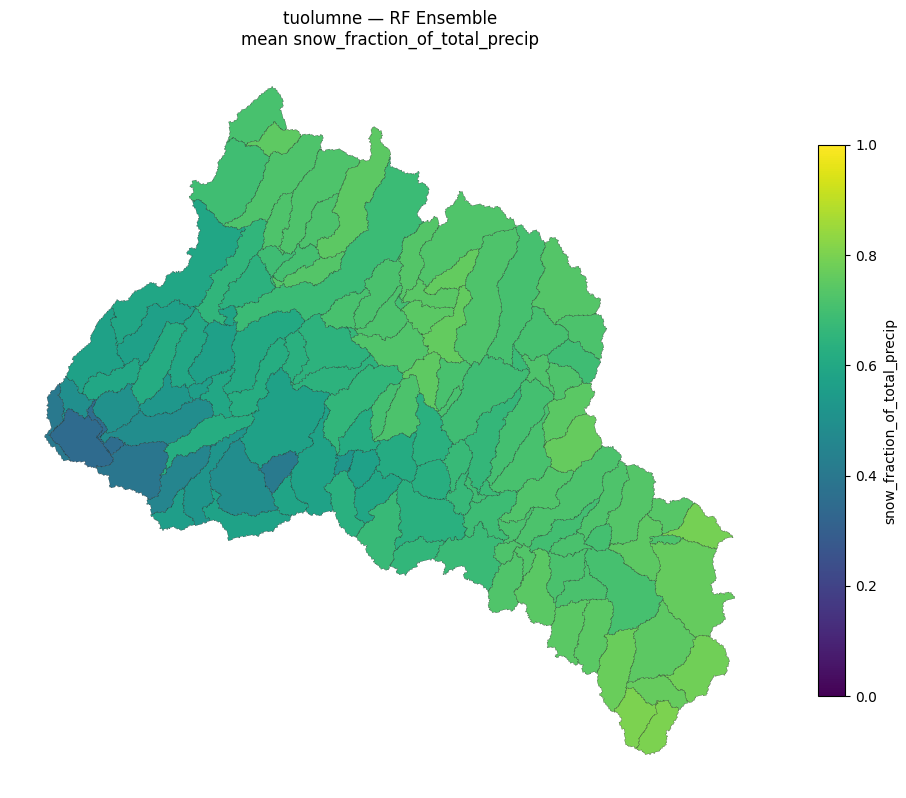

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def catchment_gpkg_path(catchment: str) -> Path:
    """Return the TauDEM HRU GeoPackage for a catchment."""
    return gpep_root / catchment / "gis" / f"{catchment}_tdx.gpkg"


def spatial_mean_per_gru(
    ds: xr.Dataset,
    var: str,
    *,
    reduce_dims: tuple[str, ...] | None = None,
) -> xr.DataArray:
    """Mean over time and ensemble member (when present), one value per ``gru``."""
    if var not in ds:
        raise KeyError(f"{var!r} not in dataset; found {list(ds.data_vars)}")
    da = ds[var]
    if reduce_dims is None:
        reduce_dims = tuple(d for d in ("time", "member") if d in da.dims)
    if not reduce_dims:
        raise ValueError(f"{var} has no time/member dims to reduce: {da.dims}")
    out = da.mean(dim=reduce_dims, skipna=True)
    if "gru" not in out.dims:
        raise ValueError(f"Expected a gru dimension after reduction; got {out.dims}")
    return out


def infer_gpkg_join_field(gru_values: np.ndarray, gdf: gpd.GeoDataFrame) -> str:
    """Pick the GeoPackage column that best matches NetCDF ``gru`` values."""
    gru_values = np.asarray(gru_values, dtype=np.int64)
    candidates: list[tuple[int, str]] = []

    for field in ("HRU_ID", "GRU_ID", "gruId", "gru_id", "hruId", "hru_id"):
        if field not in gdf.columns:
            continue
        gpkg_ids = gdf[field].astype(np.int64).values
        n_match = int(np.isin(gru_values, gpkg_ids).sum())
        if n_match:
            candidates.append((n_match, field))

    if not candidates:
        raise ValueError(
            "Could not match NetCDF gru values to the GeoPackage. "
            f"gru sample={gru_values[:8].tolist()} …; gpkg columns={list(gdf.columns)}"
        )

    candidates.sort(reverse=True)
    return candidates[0][1]


def plot_spatial_mean_on_gpkg(
    nc_path: Path | str,
    *,
    catchment: str,
    var: str = mpf.VAR_FRAC,
    source_label: str | None = None,
    gpkg_path: Path | str | None = None,
    gpkg_id_field: str | None = None,
    figsize: tuple[float, float] = (10, 8),
    cmap: str = "viridis",
    vmin: float | None = 0.0,
    vmax: float | None = 1.0,
    edgecolor: str = "black",
    linewidth: float = 0.15,
    title: str | None = None,
    ax: plt.Axes | None = None,
):
    """
    Choropleth of the temporal (and member) mean on catchment HRU polygons.

    Reads ``nc_path`` from disk. Joins ``gru`` to ``gpkg_id_field`` when set;
    otherwise auto-detects ``HRU_ID`` vs ``GRU_ID``.
    """
    nc_path = Path(nc_path)
    gpkg_path = Path(gpkg_path) if gpkg_path is not None else catchment_gpkg_path(catchment)
    if not gpkg_path.is_file():
        raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

    with open_mixed_precip_nc(nc_path, variables=[var]) as ds:
        mean_da = spatial_mean_per_gru(ds, var).load()

    gdf = gpd.read_file(gpkg_path)
    join_field = gpkg_id_field or infer_gpkg_join_field(mean_da["gru"].values, gdf)
    if join_field not in gdf.columns:
        raise KeyError(f"{gpkg_path} has no {join_field!r}; columns: {list(gdf.columns)}")

    merge_df = pd.DataFrame(
        {
            join_field: np.asarray(mean_da["gru"].values, dtype=np.int64),
            "value": np.asarray(mean_da.values, dtype=float),
        }
    )

    gdf = gdf.copy()
    gdf[join_field] = gdf[join_field].astype(np.int64)
    plot_gdf = gdf.merge(merge_df, on=join_field, how="left")

    n_missing = plot_gdf["value"].isna().sum()
    if n_missing:
        print(
            f"Warning: {n_missing} of {len(plot_gdf)} polygons have no mapped value "
            f"(joined on {join_field}; {len(merge_df)} values in NetCDF)."
        )

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    else:
        fig = ax.figure

    plot_kw = dict(
        column="value",
        cmap=cmap,
        legend=True,
        legend_kwds={"label": var, "shrink": 0.75},
        ax=ax,
        edgecolor=edgecolor,
        linewidth=linewidth,
        missing_kwds={"color": "lightgrey", "label": "no data"},
    )
    if vmin is not None:
        plot_kw["vmin"] = vmin
    if vmax is not None:
        plot_kw["vmax"] = vmax

    plot_gdf.plot(**plot_kw)

    if title is None:
        src = f" — {source_label}" if source_label else ""
        title = f"{catchment}{src}\nmean {var}"
    ax.set_title(title)
    ax.set_axis_off()

    if created_fig:
        fig.tight_layout()
    return fig, ax, plot_gdf


def plot_spatial_mean_panel(
    output_nc_by_catchment: dict[str, dict[str, Path]],
    *,
    source_label: str = "RF Ensemble",
    var: str = mpf.VAR_FRAC,
    catchments_list: list[str] | None = None,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
    **plot_kwargs,
):
    """One panel per catchment for a single source label (reads NetCDF paths from disk)."""
    catchments_list = catchments_list or list(output_nc_by_catchment.keys())
    n = len(catchments_list)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (5.5 * ncols, 5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for i, catchment in enumerate(catchments_list):
        path_dict = output_nc_by_catchment[catchment]
        if source_label not in path_dict:
            raise KeyError(
                f"{catchment}: missing source {source_label!r}; have {list(path_dict.keys())}"
            )
        plot_spatial_mean_on_gpkg(
            path_dict[source_label],
            catchment=catchment,
            var=var,
            source_label=source_label,
            ax=axes[i],
            title=f"{catchment} — {source_label}",
            **plot_kwargs,
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle(f"Spatial mean {var}", y=1.02)
    fig.tight_layout()
    return fig, axes


# --- Examples (edit catchment / source as needed) ---

catchment = catchments[0]
source_label = "RF Ensemble"

fig, ax, _ = plot_spatial_mean_on_gpkg(
    output_nc_by_catchment[catchment][source_label],
    catchment=catchment,
    vmin=0,
    vmax=1,
    source_label=source_label,
)
plt.show()

# All catchments, one source:
# fig, axes = plot_spatial_mean_panel(
#     output_nc_by_catchment,
#     source_label="RF Ensemble",
# )
# plt.show()